# 04 - Evaluation (Metrics, Confusion Matrix, Grad-CAM)

Stage 4: Evaluate the trained crop identifier on the held-out test split.

Reports:
  - overall accuracy + macro-F1 (macro-F1 matters more than accuracy given
    the Cotton class imbalance -- accuracy alone can hide poor Cotton
    recall)
  - per-class precision/recall/F1 (classification_report)
  - confusion matrix
  - accuracy broken down by environment (closed vs. uncontrolled vs.
    derived) using manifest.csv, so you can see whether the model is
    quietly relying on clean studio backgrounds
  - Grad-CAM on a handful of sample images, to sanity-check the model is
    attending to the leaf and not the background

Install deps:
    pip install grad-cam scikit-learn matplotlib seaborn --break-system-packages

NOTE on the environment breakdown: dataset_split files were renamed to
"<original_stem>_<hash>.<ext>" during materialize_split(). This lookup
matches back to manifest.csv by original stem, which is a heuristic (not
a guaranteed unique key) -- treat the per-environment numbers as
directional, not exact.

## Imports & Configuration

In [1]:
import re
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

MODEL_PATH = Path("models/crop_identifier_v1.pth")
LABELS_PATH = Path("models/crop_identifier_labels.json")
TEST_DIR = Path("dataset_split/test")
MANIFEST_PATH = Path("manifest.csv")
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

eval_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

g:\Crop Identification\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## `load_model_and_labels`

In [2]:
def load_model_and_labels():
    with open(LABELS_PATH) as f:
        classes = json.load(f)
    model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=len(classes))
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model, classes

## `build_environment_lookup`

Heuristic stem -> environment lookup. Strips the trailing

In [3]:
def build_environment_lookup(manifest_path):
    """
    Heuristic stem -> environment lookup. Strips the trailing
    "_<digits>" hash suffix Python's materialize_split() appended, and
    matches what remains against manifest.csv's original filename stems.
    """
    manifest = pd.read_csv(manifest_path)
    manifest["stem"] = manifest["filepath"].apply(lambda p: Path(p).stem)
    stem_to_env = dict(zip(manifest["stem"], manifest["environment"]))
    return stem_to_env

## `guess_original_stem`

In [4]:
def guess_original_stem(filename_stem):
    match = re.match(r"^(.*)_\d+$", filename_stem)
    return match.group(1) if match else filename_stem

## `evaluate_test_set`

In [5]:
def evaluate_test_set(model, classes, stem_to_env):
    y_true, y_pred, environments = [], [], []

    for crop_idx, crop_name in enumerate(classes):
        crop_dir = TEST_DIR / crop_name
        if not crop_dir.exists():
            continue
        for img_path in crop_dir.iterdir():
            image = cv2.imread(str(img_path))
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            tensor = eval_tf(image=image)["image"].unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                output = model(tensor)
                pred_idx = output.argmax(dim=1).item()

            y_true.append(crop_idx)
            y_pred.append(pred_idx)

            orig_stem = guess_original_stem(img_path.stem)
            environments.append(stem_to_env.get(orig_stem, "unknown"))

    return np.array(y_true), np.array(y_pred), np.array(environments)

## `print_overall_metrics`

In [6]:
def print_overall_metrics(y_true, y_pred, classes):
    print("=== Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=classes, digits=3))
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"Macro-F1: {macro_f1:.4f}")

## `plot_confusion`

In [7]:
def plot_confusion(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Crop Identifier - Confusion Matrix (Test Set)")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()

## `print_environment_breakdown`

In [8]:
def print_environment_breakdown(y_true, y_pred, environments):
    print("\n=== Accuracy by Environment ===")
    df = pd.DataFrame({"true": y_true, "pred": y_pred, "environment": environments})
    df["correct"] = df["true"] == df["pred"]
    print(df.groupby("environment")["correct"].mean())
    print("\nIf 'closed'/controlled accuracy is notably higher than "
          "'uncontrolled', the model may be leaning on clean backgrounds "
          "rather than leaf features -- worth retraining on leaf-segmented "
          "crops from 02_leaf_segmentation before trusting the model.")

## `gradcam_sample`

In [9]:
def gradcam_sample(model, classes, n_per_class=2):
    target_layer = model.conv_head  # last conv layer before pooling, for timm efficientnet
    cam = GradCAM(model=model, target_layers=[target_layer])

    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(4 * n_per_class, 4 * len(classes)))
    for row, crop_name in enumerate(classes):
        crop_dir = TEST_DIR / crop_name
        sample_paths = list(crop_dir.iterdir())[:n_per_class]
        for col, img_path in enumerate(sample_paths):
            image_bgr = cv2.imread(str(img_path))
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
            input_tensor = eval_tf(image=image_rgb)["image"].unsqueeze(0).to(DEVICE)

            grayscale_cam = cam(input_tensor=input_tensor)[0]
            visualization = show_cam_on_image(resized / 255.0, grayscale_cam, use_rgb=True)

            ax = axes[row, col] if len(classes) > 1 else axes[col]
            ax.imshow(visualization)
            ax.set_title(crop_name)
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("gradcam_samples.png", dpi=150)
    plt.show()

## Run

=== Classification Report ===
              precision    recall  f1-score   support

      Cotton      0.989     0.972     0.981       289
   Groundnut      0.994     0.999     0.996       694
 Pepper Bell      0.997     0.998     0.998      1129
      Potato      0.999     0.999     0.999      1152
      Tomato      0.991     0.992     0.991       996

    accuracy                          0.995      4260
   macro avg      0.994     0.992     0.993      4260
weighted avg      0.995     0.995     0.995      4260

Macro-F1: 0.9931


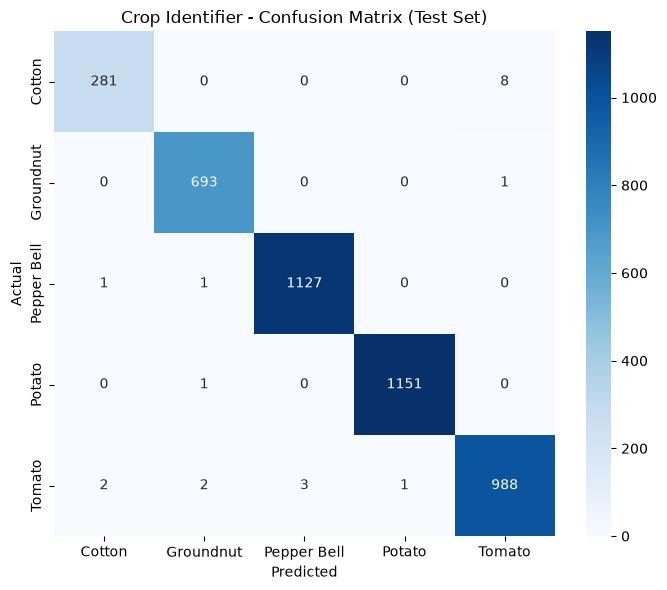


=== Accuracy by Environment ===
environment
closed          0.999641
uncontrolled    0.987084
Name: correct, dtype: float64

If 'closed'/controlled accuracy is notably higher than 'uncontrolled', the model may be leaning on clean backgrounds rather than leaf features -- worth retraining on leaf-segmented crops from 02_leaf_segmentation before trusting the model.


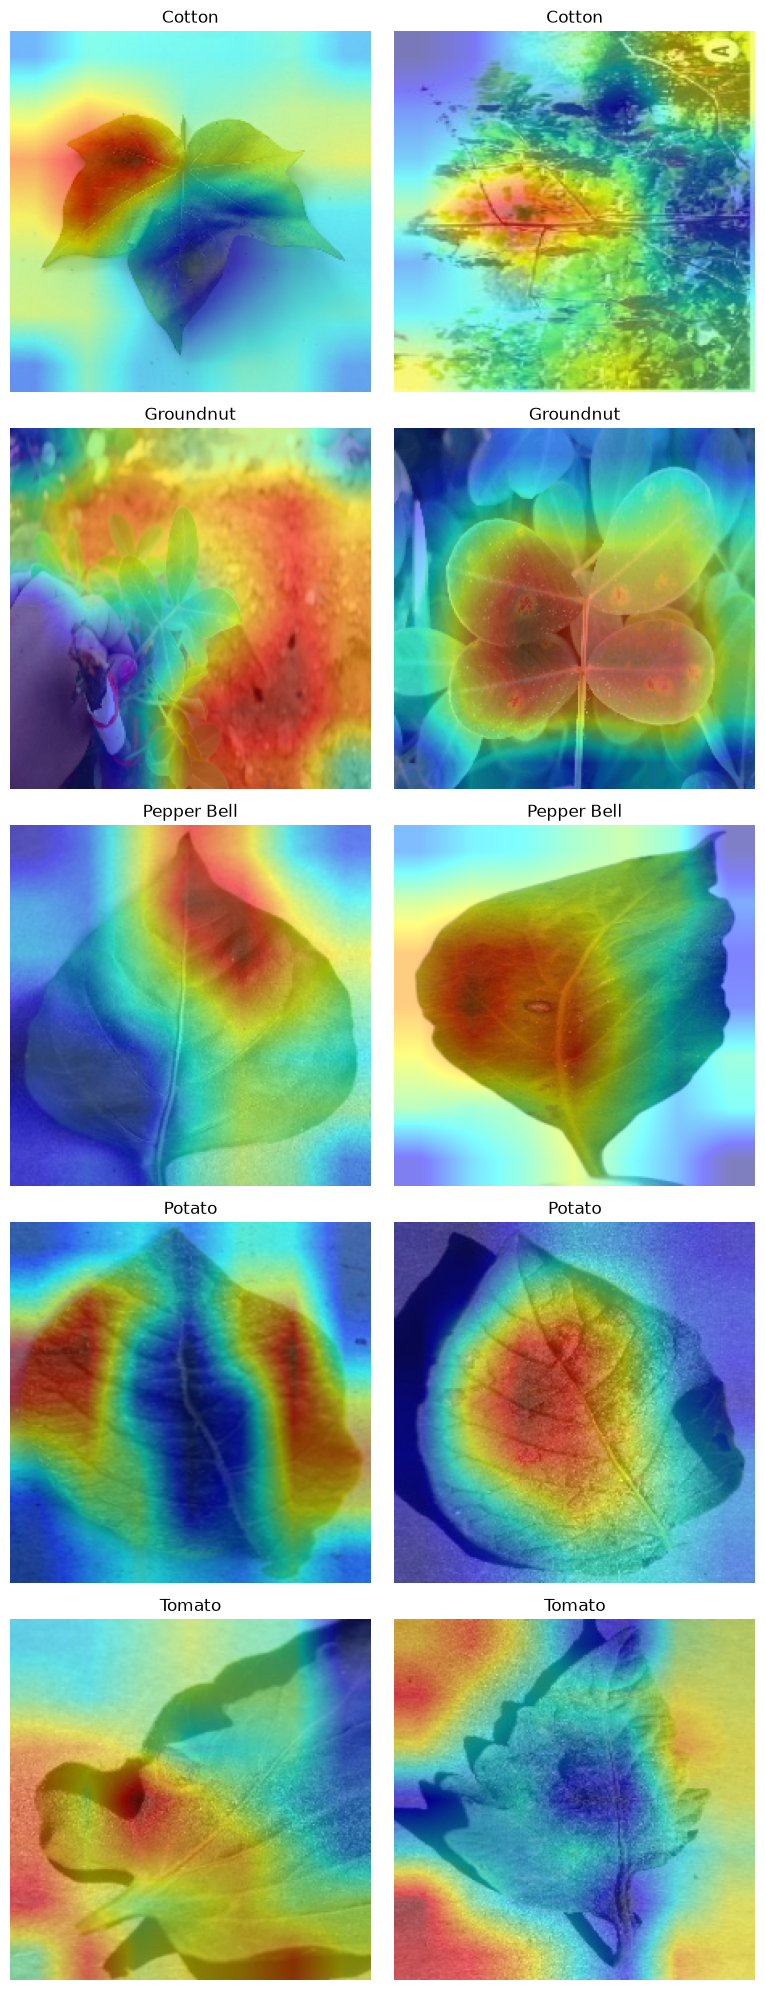

In [10]:
model, classes = load_model_and_labels()
stem_to_env = build_environment_lookup(MANIFEST_PATH)

y_true, y_pred, environments = evaluate_test_set(model, classes, stem_to_env)

print_overall_metrics(y_true, y_pred, classes)
plot_confusion(y_true, y_pred, classes)
print_environment_breakdown(y_true, y_pred, environments)
gradcam_sample(model, classes)